In [61]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from matplotlib import colors
import matplotlib.cm as cm
load_dotenv()
%matplotlib inline

# <div align='center'> Overview </div>
- We modelled the system from #14 [J. HONG et al.](/papers/main.pdf) in the form of decoupled, non dimensionalized equations [here](./model/README.md)
- Used our [solver](/core/README.md) to simulate the system on the parameters mentioned in the papaer (#15 J. HOND et al.) and did about 50 simulations around that forcing frequency to generate simulated data
- Performed a parameter sweep around the critical speed regime to study the transition from free whirl to rubbing dominated motion.
- Here we analyze if the simulations match the general results as presented in the paper 

##### **NOTE**: Simulation data won't be included in the GitHub Repo, one can generate it using the steps in README file, here the data generated on my machine was used to get the plots

In [26]:
PAPER_TRAJECTORY = os.environ.get("PAPER_TRAJECTORY")
PAPER_METADATA = os.environ.get("PAPER_METADATA")
paper_trajectory = np.load(PAPER_TRAJECTORY)
paper_metadata = pd.read_csv(PAPER_METADATA)

t = paper_trajectory['t']
X,Y = paper_trajectory['y'][:,0],paper_trajectory['y'][:,1]
R = np.sqrt(X**2 + Y**2)
Xdot,Ydot = paper_trajectory['y'][:,2],paper_trajectory['y'][:,3]

paper_metadata.head()

,Unnamed: 0,f_shaft,ecc,kc,mu,r_disk,R_mean,R_std,R_max,R_min,...,y_std,orbit_dispersion,x_dom_freq,x_dom_amp,y_dom_freq,y_dom_amp,whirl_freq,spectral_entropy,crest_factor,Omega_bar
0,0,50.0,0.0005,690872.308076,0.01,10.0,1.062028,0.080106,1.303669,0.01,...,0.753487,1.78178,0.159075,1.088856e+06,0.159075,1.099009e+06,0.159075,6.725517,13.132895,1.0


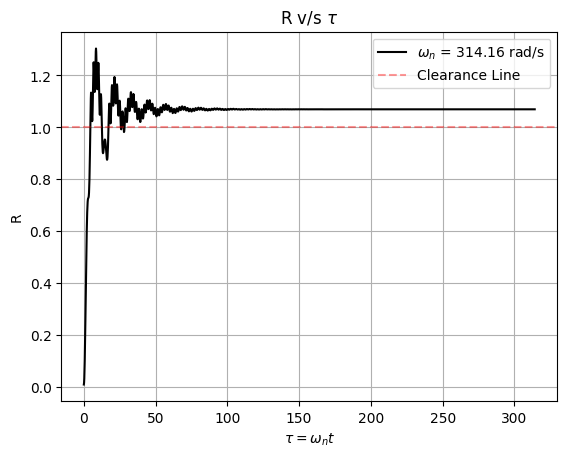

In [27]:
## trajectory evolution

plt.plot(t,R,color='k',label=r'$\omega_n$ = {omega:.2f} rad/s'.format(omega=2*np.pi*paper_metadata['f_shaft'].item()))
plt.title(r"R v/s $\tau$")
plt.xlabel(r"$\tau = \omega_n t$")
# plt.text(200,1.25)
plt.ylabel('R')
plt.axhline(y=1.0,color='red',linestyle='--',alpha=0.4,label='Clearance Line')
plt.legend()
plt.grid()
plt.show()

> The transient response initially exhibits resonance-driven orbit growth.

> As the orbit approaches the clearance boundary (R=1), rubbing activates and limits further amplitude growth throught non-linear contact forces.

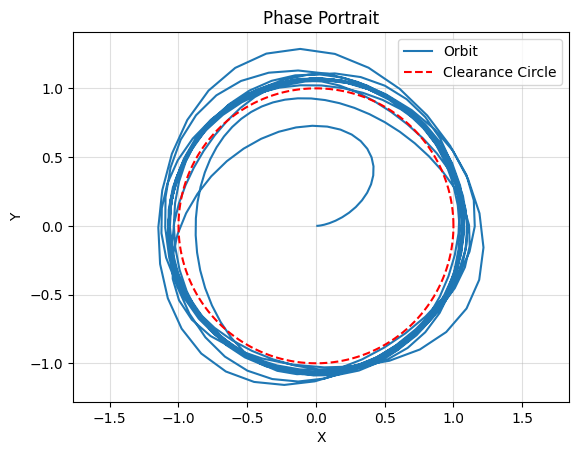

In [28]:
##Orbit plot
theta = np.linspace(0,2*np.pi,1000)
plt.plot(X,Y,label='Orbit')
plt.plot(np.cos(theta),np.sin(theta),label='Clearance Circle',color='red',linestyle='--')
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(alpha=0.4)
plt.title("Phase Portrait")
plt.legend()
plt.show()

> The orbit evolves from approximately circular free whirl motion into a distorted rubbing trajectory constrained by the stator clearance boundary.

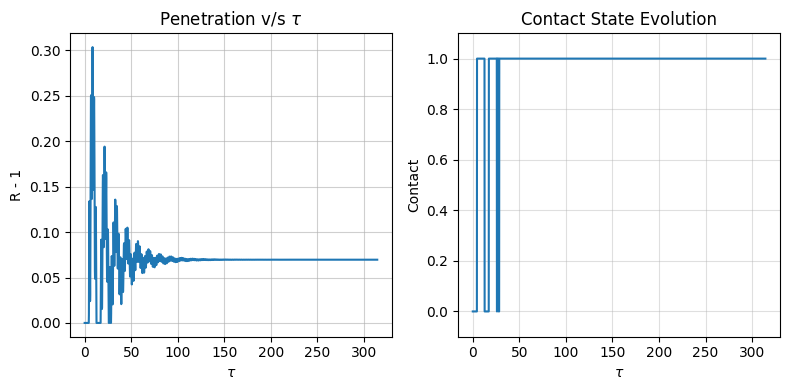

In [29]:
fig,ax = plt.subplots(1,2,figsize=(8,4))

penetration = np.clip(R - 1.0,0.0,float('inf'))
plt.sca(ax[0])
plt.plot(t,penetration)
plt.title(r'Penetration v/s $\tau$')
plt.ylabel('R - 1')
plt.xlabel(r'$\tau$')
plt.grid(alpha=0.6)


contact = (R > 1.0).astype(float)
plt.sca(ax[1])
plt.plot(t, contact)
plt.ylim(-0.1, 1.1)
plt.title("Contact State Evolution")
plt.xlabel(r'$\tau$')
plt.ylabel('Contact')
plt.grid(alpha=0.4)

plt.tight_layout()

# Omega Sweep Analysis

In [30]:
OMEGA_SWEEP_ = os.environ.get('SWEEP_METADATA')
df = pd.read_csv(OMEGA_SWEEP_)
df.head()


,Unnamed: 0,f_shaft,ecc,kc,mu,r_disk,R_mean,R_std,R_max,R_min,...,orbit_dispersion,x_dom_freq,x_dom_amp,y_dom_freq,y_dom_amp,whirl_freq,spectral_entropy,crest_factor,Omega_bar,e_bar
0,0,25.0,0.000100,690872.308076,0.01,10.0,0.033259,8.226890e-08,0.033260,0.033259,...,0.001734,0.08484,43.614683,0.074235,42.548045,0.079538,5.022074,4.764294,0.5,0.100000
1,0,25.0,0.000178,690872.308076,0.01,10.0,0.059128,1.647506e-07,0.059129,0.059127,...,0.005482,0.08484,137.843932,0.074235,134.472840,0.079538,4.187635,4.950316,0.5,0.177778
2,0,25.0,0.000256,690872.308076,0.01,10.0,0.084996,2.477385e-07,0.084998,0.084996,...,0.011328,0.08484,284.841555,0.074235,277.875522,0.079538,3.980335,5.069106,0.5,0.255556
3,0,25.0,0.000333,690872.308076,0.01,10.0,0.110865,3.306211e-07,0.110867,0.110864,...,0.019272,0.08484,484.607558,0.074235,472.756093,0.079538,3.889521,5.045802,0.5,0.333333
4,0,25.0,0.000411,690872.308076,0.01,10.0,0.136733,4.136079e-07,0.136736,0.136732,...,0.029315,0.08484,737.141946,0.074235,719.114554,0.079538,3.863358,5.057552,0.5,0.411111


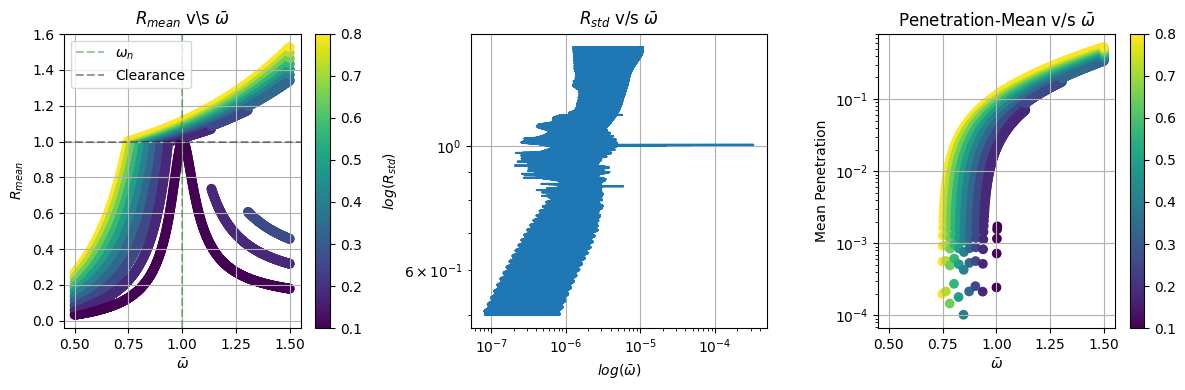

In [31]:
fig,ax = plt.subplots(1,3,figsize=(12,4))

plt.sca(ax[0])
plt.scatter(df['Omega_bar'],df['R_mean'],c=df['e_bar'])
plt.colorbar()
plt.title(r'$R_{mean}$ v\s $\bar{\omega}$')
plt.axvline(x=1,color='green',linestyle='--',alpha=0.4,label=r'$\omega_n$')
plt.axhline(y=1,color='k',linestyle='--',alpha=0.4,label='Clearance')
plt.xlabel(r'$\bar{\omega}$')
plt.ylabel(r'$R_{mean}$')
plt.legend()
plt.grid()

plt.sca(ax[1])
plt.plot(df['R_std'],df['Omega_bar'])
plt.xscale('log')
plt.yscale('log')
plt.title(r'$R_{std}$ v/s $\bar{\omega}$')
plt.xlabel(r'$log(\bar{\omega})$')
plt.ylabel(r'$log(R_{std})$')
plt.grid()

plt.sca(ax[-1])
plt.scatter(df['Omega_bar'],df['penetration_mean'],c=df['e_bar'])
plt.yscale('log')
plt.colorbar()
plt.xlabel(r'$\bar{\omega}$')
plt.ylabel(r'Mean Penetration')
plt.grid()
plt.title(r'Penetration-Mean v/s $\bar{\omega}$')

plt.tight_layout()

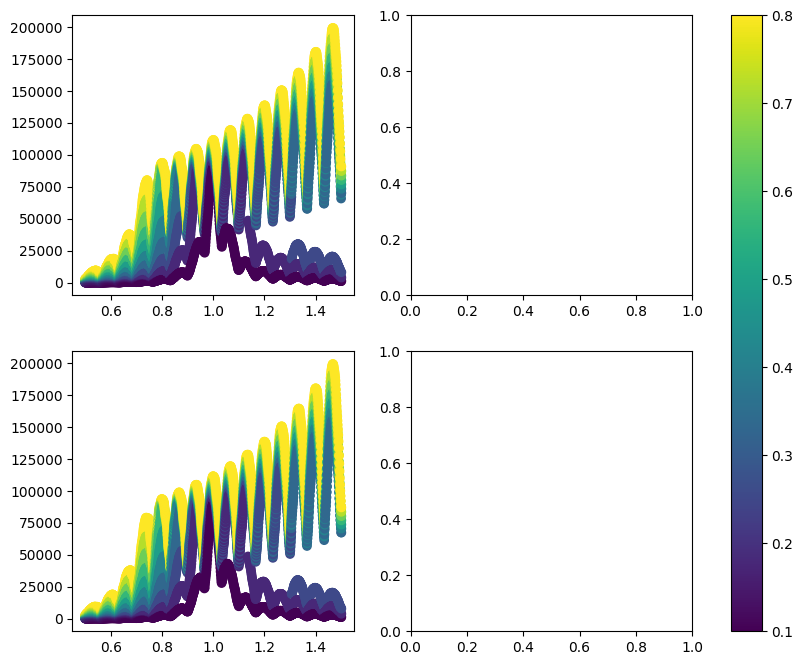

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
norm = colors.Normalize(vmin=0.1,vmax=0.8)
sm = cm.ScalarMappable(cmap='viridis',norm=norm)
sm.set_array([])
fig.colorbar(sm,ax=ax.ravel().tolist())

plt.sca(ax[0,0])
plt.scatter(df["Omega_bar"],df['x_dom_amp'],c=df['e_bar'])

plt.sca(ax[1,0])
plt.scatter(df["Omega_bar"],df['y_dom_amp'],c=df['e_bar'])


# plt.tight_layout()